In [26]:
!pip install datasets

# **Load Dataset**

In [27]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

In [28]:
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [29]:
df = dataset["train"].to_pandas()

In [30]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


#**Understand labels**

In [31]:
dataset["train"].features["label"].names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [32]:
label_names = dataset["train"].features["label"].names

df["emotion"] = df["label"].map(lambda x: label_names[x])

In [33]:
df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


# **Data cleaning**

In [34]:
df.isnull().sum()

,0
text,0
label,0
emotion,0


Our dataset has no missing value.

# **Check our emotion distribution**

In [35]:
df["emotion"].value_counts()

,count
emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


#**Make our first chart**

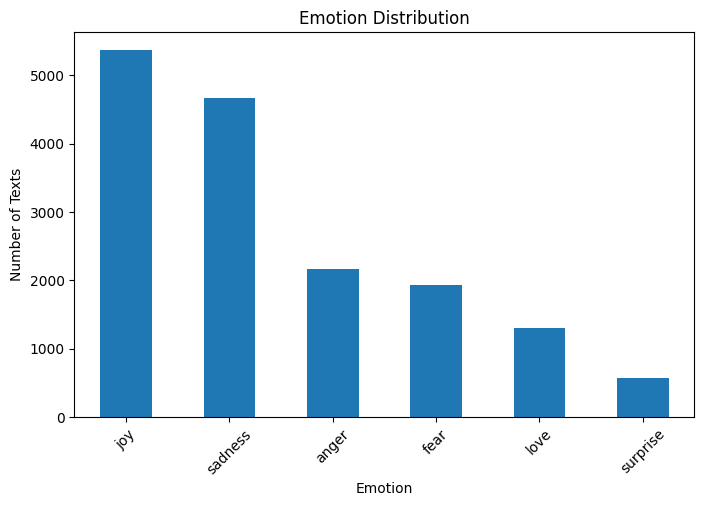

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df["emotion"].value_counts().plot(kind="bar")

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Texts")
plt.xticks(rotation=45)

plt.show()

In [37]:
for emotion in df["emotion"].unique():
    print("\n---", emotion.upper(), "---")
    print(df[df["emotion"] == emotion]["text"].head(3).to_string(index=False))


--- SADNESS ---
                           i didnt feel humiliated
i can go from feeling so hopeless to so damned ...
ive been feeling a little burdened lately wasnt...

--- ANGER ---
  im grabbing a minute to post i feel greedy wrong
                              i am feeling grouchy
i think it s the easiest time of year to feel d...

--- LOVE ---
i am ever feeling nostalgic about the fireplace...
                               i feel romantic too
i can t let go of that sad feeling that i want ...

--- SURPRISE ---
ive been taking or milligrams or times recommen...
i have seen heard and read over the past couple...
i keep feeling pleasantly surprised at his supp...

--- FEAR ---
i feel as confused about life as a teenager or ...
i now feel compromised and skeptical of the val...
i am feeling completely overwhelmed i have two ...

--- JOY ---
i have been with petronas for years i feel that...
i do feel that running is a divine experience a...
i have immense sympathy with the general p

I inspected representative samples from each emotion category to understand the relationship between the text and its assigned label.

# **Basic text analysis**

In [38]:
df["word_count"] = df["text"].str.split().str.len()

In [39]:
df["word_count"].describe()

,word_count
count,16000.000000
mean,19.166313
std,10.986905
min,2.000000
25%,11.000000
50%,17.000000
75%,25.000000
max,66.000000


###**Average words for each emotion**

In [40]:
df.groupby("emotion")["word_count"].mean()

,word_count
emotion,
anger,19.229736
fear,18.844605
joy,19.498135
love,20.700153
sadness,18.361980
surprise,19.970280


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [42]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# **Create X and y**

### **X = input/features**

In [43]:
X = df["text"]

###**y = target/output**

In [44]:
y = df["label"]

# **Train/test split**

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
stratify=y

# **Convert text into TF-IDF**

In [47]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

# **Train Logistic Regression**

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

#**Make predictions**

In [50]:
y_pred = model.predict(X_test_tfidf)

#**Evaluate the model**

In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8684375


#**Classification Report**

In [52]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=dataset["train"].features["label"].names
))

              precision    recall  f1-score   support

     sadness       0.91      0.92      0.91       933
         joy       0.83      0.95      0.89      1072
        love       0.85      0.63      0.72       261
       anger       0.91      0.84      0.88       432
        fear       0.86      0.81      0.83       387
    surprise       0.89      0.55      0.68       115

    accuracy                           0.87      3200
   macro avg       0.87      0.78      0.82      3200
weighted avg       0.87      0.87      0.87      3200



# **Confusion matrix**

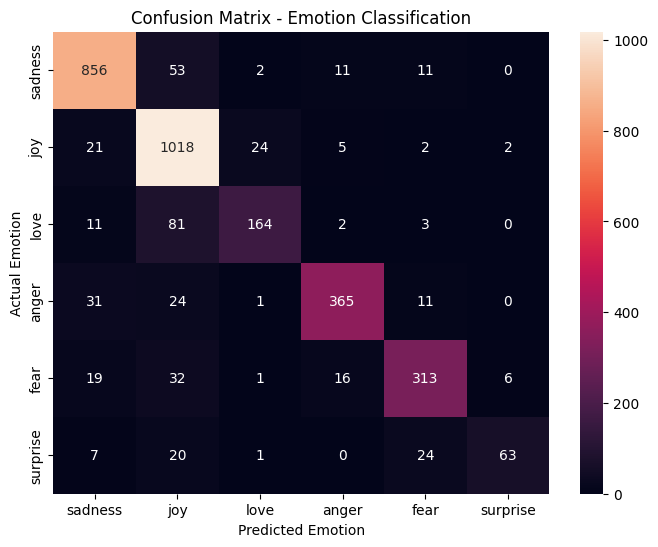

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset["train"].features["label"].names,
    yticklabels=dataset["train"].features["label"].names
)

plt.title("Confusion Matrix - Emotion Classification")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.show()

#**Test YOUR OWN sentences**

In [54]:
label_names = dataset["train"].features["label"].names

def predict_emotion(text):
    text_tfidf = tfidf.transform([text])

    prediction = model.predict(text_tfidf)[0]

    emotion = label_names[prediction]

    return emotion

In [55]:
print(predict_emotion("I am extremely happy today!"))

joy


In [56]:
print(predict_emotion("I feel very lonely and sad."))

sadness


In [57]:
print(predict_emotion("I am so angry with what happened."))

anger


In [58]:
print(predict_emotion("I am scared about what will happen tomorrow."))

fear


In [59]:
print(predict_emotion("I love spending time with my family."))

joy


**Observation:** The emotion classification model achieved an overall accuracy of approximately 86.84%. The model performed particularly well on sadness and joy, with F1-scores of 0.91 and 0.89 respectively. Anger and fear also showed good performance. However, love and surprise were more difficult for the model to distinguish, with F1-scores of 0.72 and 0.68. The confusion matrix shows that love is frequently misclassified as joy, while surprise is sometimes confused with fear and joy.

#**Saving the Trained Model and TF-IDF Vectorizer**

After training and evaluating the emotion classification model, I saved both the trained machine learning model and the TF-IDF vectorizer using the joblib library.

The TF-IDF vectorizer is responsible for converting text into the numerical format that the model was trained on. The trained model uses those numerical features to predict the emotion of new text.

Both objects need to be saved so that they can be reused later without retraining the model.

tfidf_vectorizer.pkl → stores the fitted TF-IDF vectorizer.
emotion_model.pkl → stores the trained emotion classification model.

In [60]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(model, "emotion_model.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


**What happens when this code runs?**
1. import joblib imports the library used to save Python objects.
2. joblib.dump(tfidf, "tfidf_vectorizer.pkl") saves the fitted TF-IDF vectorizer into a .pkl file.
3. joblib.dump(model, "emotion_model.pkl") saves the trained machine learning model into another .pkl file.
4. These files can later be loaded into another Python program, such as the Streamlit application.
5. The Streamlit application can then take new text from the user, transform it using the saved TF-IDF vectorizer, and send the resulting features to the saved model for prediction.

**One important point:** We save the fitted TF-IDF vectorizer, not just a new empty TfidfVectorizer(). This is because the saved vectorizer already knows the vocabulary and TF-IDF transformation learned during training.